<a href="https://colab.research.google.com/github/Rojoniaina-Rasoafarihy/Polarization_detection/blob/main/train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive/evo2_embeddings_filter_embeddings_block28.npz

/content/drive/MyDrive/evo2_embeddings_filter_embeddings_block28.npz


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
data = np.load("/content/drive/MyDrive/evo2_embeddings_filter_embeddings_block28.npz")
X = data['X']          # shape (n_samples, embedding_dim)
y = data['y']          # 0 = avirulent, 1 = virulent

print(f"Data shape: {X.shape}")
print(f"Class counts: {np.bincount(y)}")

#  Train/Test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

#  Train logistic regression
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train, y_train)

#  Predictions
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]   # probability for class 1 (virulent)

#  Metrics
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["AVIRULENT", "VIRULENT"]))

print("ROC AUC:", roc_auc_score(y_test, y_proba))

Data shape: (504192, 4096)
Class counts: [ 34310 469882]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Classification Report:
              precision    recall  f1-score   support

   AVIRULENT       0.91      0.86      0.89      6862
    VIRULENT       0.99      0.99      0.99     93977

    accuracy                           0.99    100839
   macro avg       0.95      0.93      0.94    100839
weighted avg       0.99      0.99      0.99    100839

ROC AUC: 0.9941615457625429


## UMAP

In [ ]:
!pip install umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 8.5 MB/s eta 0:00:00


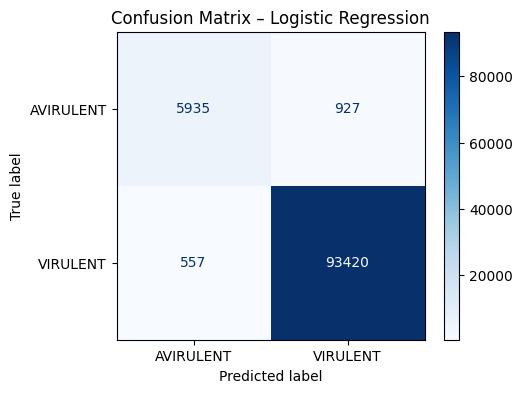

Computing UMAP...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/usr/local/lib/python3.12/dist-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/usr/local/lib/python3.12/dist-packages/umap/spectral.py:548: UserWarning: Spect

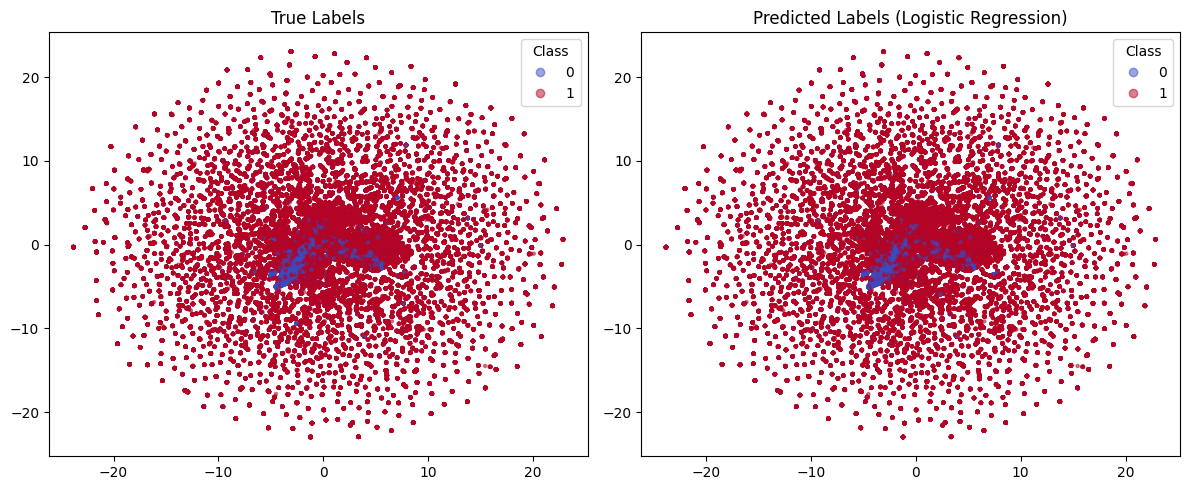

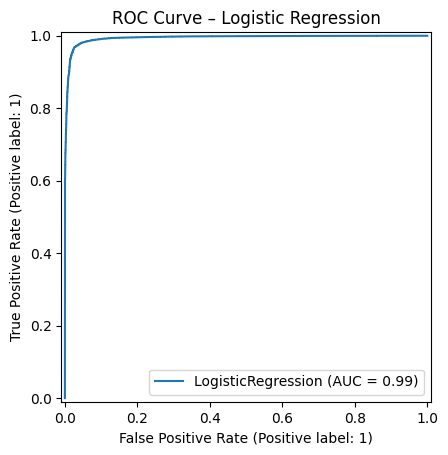

In [ ]:
import umap
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

# 1. Confusion Matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, labels=[0, 1], display_labels=["AVIRULENT", "VIRULENT"],
                                        cmap='Blues', ax=ax)
ax.set_title("Confusion Matrix – Logistic Regression")
plt.show()

# 2. UMAP projection (on test set for clarity)
print("Computing UMAP...")
reducer = umap.UMAP(n_components=2, random_state=42, n_jobs=-1)
X_test_2d = reducer.fit_transform(X_test)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
# True labels
scatter1 = ax1.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=y_test, cmap='coolwarm',
                       alpha=0.5, s=5)
ax1.set_title("True Labels")
ax1.legend(*scatter1.legend_elements(), title="Class")

# Predicted labels
scatter2 = ax2.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=y_pred, cmap='coolwarm',
                       alpha=0.5, s=5)
ax2.set_title("Predicted Labels (Logistic Regression)")
ax2.legend(*scatter2.legend_elements(), title="Class")

plt.tight_layout()
plt.show()

# 3. ROC Curve
RocCurveDisplay.from_estimator(clf, X_test, y_test)
plt.title("ROC Curve – Logistic Regression")
plt.show()